**Author**: Felipe Matheus  
**Pipeline**: Uncertainty-aware Model-Based Controller (MBC) — Annealing

Probabilistic counterpart of the deterministic `mbc_annealing_ngsz.ipynb`. Same
shape — fix the material state, sweep a dense (temperature, time) grid, predict
every cell, filter by setpoints, rank by cost, export — but every prediction is
now a **calibrated Gaussian predictive distribution** instead of a point, and the
hard setpoint filter `pred >= min` becomes the chance constraint
**Pr(Y >= y_target) >= 1 - delta** (copper_digital_twin_v4 §2.1).

What changed vs. the deterministic MBC:
- **Models**: AutoGluon artifact down_bundles (`artifacts.pkl` + `model_a/` + `model_b/`)
  from the annealing notebooks — NOT H2O + scalers. AutoGluon preprocesses
  internally, so there are no manual scalers here.
- **Prediction**: `mu, sigma_total` (epistemic + aleatoric, recalibrated, truncated)
  per cell, via `MBCInference` → `Modeling.predict_with_uncertainty`.
- **Feasibility**: `Pr(Y >= setpoint)` under the truncated law, gated at `1 - delta`.
- **Ranking**: still cost-based, plus optional risk-aware LCB (`mu - kappa*sigma`).

# 1. Setup

In [10]:
import os
import sys
import logging
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.DataLoader import LoaderHelper
from src.modeling.Modeling import Modeling
from src.modeling.MBCInference import MBCInference
from src.metrics.ProbabilisticEvaluation import ProbabilisticEvaluation
from src.feature_engineering.ChemicalFeatureEngineering import ChemicalFeatureEngineering
from config.bags_compositions import ALL_SAMPLES
from config.elements_coefficients import RESISTIVITY_FACTORS, ENRICHMENT_FACTORS
from config.Variables import Variables


logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s")

%load_ext autoreload
%autoreload 2

modl = Modeling()
load = LoaderHelper()
varv = Variables()
mbc = MBCInference(modl, load)
pev = ProbabilisticEvaluation()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Configuration

`material_properties` are the FIXED features of the current state (everything the
surrogates need except temperature/time, which are swept). `operational_limits`
and `step` define the grid; `min_setpoints` the targets; `delta` the risk knob.

In production these come from `config/config_script_annealing.yaml`; here they are
inline for clarity. Note the bundle dirs point at the run folders produced by
Section 10 of the annealing notebooks (or any `<run_dir>` from ExperimentRunner).

In [28]:
# ---- Surrogate artifact down_bundles (each: artifacts.pkl + model_a/ + model_b/) ----
# ---- TAG folders (best run auto-picked by RMSE, no hard-coded hash) ----
IACS_TAG_DIR = os.path.join(varv.PATHS.models, "annealing_iacs",
                            "model_annealing_iacs_020926_LT-18")
UTS_TAG_DIR  = os.path.join(varv.PATHS.models, "annealing_tensile-strength",
                            "model_annealing_tensile-strength_020926_LT-18")
ELONGATION_TAG_DIR  = os.path.join(varv.PATHS.models, "annealing_elongation",
                            "model_annealing_elongation_020926_LT-18")

# ---- Serial number encoding schema (for chemical feature engineering) ----
SN_SCHEMA_DATE = "020926"
DF_SN = pd.read_csv(os.path.join(
    varv.PATHS.data_structured, f"serial-number-encoding_{SN_SCHEMA_DATE}.csv"
))
chfe = ChemicalFeatureEngineering(
    all_samples=ALL_SAMPLES,
    df_sn=DF_SN,
    resistivity_factors=RESISTIVITY_FACTORS,
    enrichment_factors=ENRICHMENT_FACTORS,
)


down_bundles = mbc.load_surrogates_best(
    {"iacs": IACS_TAG_DIR,
     "uts": UTS_TAG_DIR,
     "elongation": ELONGATION_TAG_DIR},
     metric="rmse",
)

TARGETS = ("iacs", "tensile_strength", "elongation")

# ---- Fixed material state (features other than temperature/time) ----
# Must contain every non-grid feature each surrogate needs:
#   IACS needs: purity, iacs        UTS needs: purity, initial_diameter, tensile_strength
MATERIAL_PROPERTIES = {
    "purity": 99.6985,
    "material_reference": "SN027", #TODO
    "initial_diameter": 1.0,
    "iacs": 94.4,
    "tensile_strength": 250.0,
    "elongation": 6.39, #TODO
}

# ---- Grid (inclusive of upper bound, like the deterministic build_param_grid) ----
OPERATIONAL_LIMITS = {
    "temperature": [523, 723],   # Kelvin
    "time": [30, 120],           # minutes
}
STEP = {"temperature": 10, "time": 5}

# ---- Probabilistic acceptance ----
# Keys are surrogate SHORT NAMES (bundle.target minus '_final'), not the bundle
# aliases above: 'uts' loads the surrogate whose short name is 'tensile_strength'.
MIN_SETPOINTS = {"iacs": 100.2,
                 "tensile_strength": 210.0} # short_name -> minimum (floor)

MAX_SETPOINTS = {"elongation": 50.0} # short_name -> maximum (ceiling) #TODO

DELTA = 0.10                                    # keep cells with Pr >= 1 - delta
KAPPA = 1.645                                   # one-sided 95% LCB/UCB for risk ranking

# ---- Selection criteria (mirror the deterministic labels) ----
SELECTION_SPEC_LOW = {
    "lowest_time": "time",
    "lowest_temperature": "temperature",
    "lowest_cost": "cost",
    "lowest_cost_phys": "cost_phys",
}
# The probability-based spec is DERIVED from the validated targets in §8
# (pev.build_probability_selection_spec) so its labels and its columns can
# never drift apart — hand-writing "safest_uts": "pr_success_uts" silently
# dropped that selection, because the column is pr_success_tensile_strength.

2026-09-04 19:55:42,995 | INFO | src.modeling.MBCInference | Loaded surrogate 'iacs' (features=['initial_diameter', 'IRI', 'purity', 'iacs', 'temperature', 'time']) from ..\..\models\annealing_iacs\model_annealing_iacs_020926_LT-18
2026-09-04 19:55:43,279 | INFO | src.modeling.MBCInference | Loaded surrogate 'tensile_strength' (features=['initial_diameter', 'GBEI', 'purity', 'tensile_strength', 'temperature', 'time']) from ..\..\models\annealing_tensile-strength\model_annealing_tensile-strength_020926_LT-18
2026-09-04 19:55:43,576 | INFO | src.modeling.MBCInference | Loaded surrogate 'elongation' (features=['initial_diameter', 'GBEI', 'tensile_strength', 'purity', 'elongation', 'temperature', 'time']) from ..\..\models\annealing_elongation\model_annealing_elongation_020926_LT-18


# 3. Load surrogates

In [12]:
# down_bundles = mbc.load_surrogates(BUNDLE_DIRS)
for key, b in down_bundles.items():
    art = b.artifacts
    print(f"[{key}] target={b.target} | features={b.features}")
    print(f"      recalibration_c={art['recalibration_c']:.4f} | "
          f"y_min={art.get('y_min')} y_max={art.get('y_max')}")

[iacs] target=iacs_final | features=['initial_diameter', 'IRI', 'purity', 'iacs', 'temperature', 'time']
      recalibration_c=1.3539 | y_min=None y_max=105.0
[uts] target=tensile_strength_final | features=['initial_diameter', 'GBEI', 'purity', 'tensile_strength', 'temperature', 'time']
      recalibration_c=1.8197 | y_min=None y_max=None
[elongation] target=elongation_final | features=['initial_diameter', 'GBEI', 'tensile_strength', 'purity', 'elongation', 'temperature', 'time']
      recalibration_c=1.9324 | y_min=None y_max=None


# 4. Build the (temperature, time) grid

The fixed material state is broadcast across every grid cell. Each surrogate will
later pick only the columns it needs, so IACS (4 features) and UTS (5 features)
share the same frame.

In [15]:
param_grid = mbc.build_param_grid(OPERATIONAL_LIMITS, STEP)
df_grid = mbc.build_state_grid_df(MATERIAL_PROPERTIES, param_grid)
df_grid_chfe = chfe.add_features(df_grid)

print(f"Grid: {len(param_grid['temperature'])} temperatures x "
      f"{len(param_grid['time'])} times = {len(df_grid_chfe)} cells")
df_grid_chfe.head()

Grid: 21 temperatures x 19 times = 399 cells


,purity,material_reference,initial_diameter,iacs,tensile_strength,elongation,temperature,time,IRI,GBEI
0,99.6985,SN027,1.0,94.4,250.0,6.39,523,30,0.542737,0.268018
1,99.6985,SN027,1.0,94.4,250.0,6.39,523,35,0.542737,0.268018
2,99.6985,SN027,1.0,94.4,250.0,6.39,523,40,0.542737,0.268018
3,99.6985,SN027,1.0,94.4,250.0,6.39,523,45,0.542737,0.268018
4,99.6985,SN027,1.0,94.4,250.0,6.39,523,50,0.542737,0.268018


# 5. Predict — full predictive distribution per cell

`predict_all` runs each surrogate's `predict_with_uncertainty` (epistemic +
aleatoric variance, OOD inflation, scalar recalibration, physical truncation) and
merges the distribution columns. For surrogate `s` you get `s_mu`, `s_sigma`,
`s_sigma2_epist`, `s_sigma2_aleat`, `s_ood_multiplier` (+ truncation columns when
the surrogate has a finite physical bound, e.g. IACS at 105).

In [18]:
df_pred = mbc.predict_all(down_bundles, df_grid_chfe, ood_gamma=1.0)

2026-09-04 19:26:52,841 | INFO | src.modeling.Modeling | OOD inflation applied to 188/399 rows (max m=1.21).
2026-09-04 19:26:55,477 | INFO | src.modeling.Modeling | OOD inflation applied to 399/399 rows (max m=2.29).
2026-09-04 19:26:57,327 | INFO | src.modeling.Modeling | OOD inflation applied to 399/399 rows (max m=2.29).


In [19]:
df_pred

,purity,material_reference,initial_diameter,iacs,tensile_strength,elongation,temperature,time,IRI,GBEI,...,tensile_strength_mu,tensile_strength_sigma,tensile_strength_sigma2_epist,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,elongation_mu,elongation_sigma,elongation_sigma2_epist,elongation_sigma2_aleat,elongation_ood_multiplier
0,99.6985,SN027,1.0,94.4,250.0,6.39,523,30,0.542737,0.268018,...,294.880873,4.179645,0.032459,5.243437,2.210956,19.405942,3.611944,0.308441,3.185356,2.183269
1,99.6985,SN027,1.0,94.4,250.0,6.39,523,35,0.542737,0.268018,...,294.878138,4.177746,0.027667,5.243437,2.195297,19.405942,3.609870,0.304430,3.185356,2.169026
2,99.6985,SN027,1.0,94.4,250.0,6.39,523,40,0.542737,0.268018,...,294.878138,4.177623,0.027356,5.243437,2.181915,19.405942,3.608146,0.301097,3.185356,2.157119
3,99.6985,SN027,1.0,94.4,250.0,6.39,523,45,0.542737,0.268018,...,294.878138,4.177524,0.027107,5.243437,2.170852,19.405942,3.606772,0.298442,3.185356,2.147586
4,99.6985,SN027,1.0,94.4,250.0,6.39,523,50,0.542737,0.268018,...,289.943204,4.182016,0.038446,5.243437,2.162142,20.997793,4.771301,2.911265,3.185356,2.140460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,99.6985,SN027,1.0,94.4,250.0,6.39,723,100,0.542737,0.268018,...,240.552705,6.853499,8.941981,5.243437,2.003653,51.995537,3.734460,0.549477,3.185356,1.975351
395,99.6985,SN027,1.0,94.4,250.0,6.39,723,105,0.542737,0.268018,...,240.562077,6.975245,9.450442,5.243437,2.032754,51.995537,3.742469,0.565514,3.185356,2.003970
396,99.6985,SN027,1.0,94.4,250.0,6.39,723,110,0.542737,0.268018,...,240.562077,7.044324,9.742920,5.243437,2.063969,51.995537,3.751195,0.583027,3.185356,2.034763
397,99.6985,SN027,1.0,94.4,250.0,6.39,723,115,0.542737,0.268018,...,240.562077,7.118276,10.059230,5.243437,2.097206,51.995537,3.760634,0.602015,3.185356,2.067631


In [23]:
dist_cols = [c for c in df_pred.columns
             if any(c.startswith(f"{target}_") for target in TARGETS)]
df_pred[["temperature", "time"] + dist_cols].head()

,temperature,time,iacs_mu,iacs_sigma,iacs_sigma2_epist,iacs_sigma2_aleat,iacs_ood_multiplier,iacs_mu_trunc,iacs_sigma_trunc,iacs_p_above_max,tensile_strength_mu,tensile_strength_sigma,tensile_strength_sigma2_epist,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,elongation_mu,elongation_sigma,elongation_sigma2_epist,elongation_sigma2_aleat,elongation_ood_multiplier
0,523,30,98.114144,1.193269,0.661603,0.115154,1.205211,98.114144,1.193269,3.949890e-09,294.880873,4.179645,0.032459,5.243437,2.210956,19.405942,3.611944,0.308441,3.185356,2.183269
1,523,35,98.162050,1.177344,0.641009,0.115154,1.177365,98.162049,1.177344,3.162170e-09,294.878138,4.177746,0.027667,5.243437,2.195297,19.405942,3.609870,0.304430,3.185356,2.169026
2,523,40,98.211963,1.166970,0.627742,0.115154,1.152025,98.211963,1.166970,2.999112e-09,294.878138,4.177623,0.027356,5.243437,2.181915,19.405942,3.608146,0.301097,3.185356,2.157119
3,523,45,98.261284,1.161699,0.621047,0.115154,1.129360,98.261284,1.161699,3.301118e-09,294.878138,4.177524,0.027107,5.243437,2.170852,19.405942,3.606772,0.298442,3.185356,2.147586
4,523,50,98.429794,1.228388,0.707998,0.115154,1.109534,98.429794,1.228387,4.430846e-08,289.943204,4.182016,0.038446,5.243437,2.162142,20.997793,4.771301,2.911265,3.185356,2.140460


# 6. Probabilistic feasibility — Pr(setpoint window)

The deterministic controller kept cells where `pred >= min`. Here we compute, under
the calibrated **truncated** predictive law, the probability each target sits inside
its acceptance window, then gate at `Pr >= 1 - delta`. `pr_success_all` multiplies the
per-target probabilities (independence assumption — conservative and transparent).

Two kinds of constraint, one mechanism:

| dict | meaning | probability computed | risk-aware column |
|---|---|---|---|
| `MIN_SETPOINTS` | floor — IACS, tensile strength must **reach** it | `Pr(Y >= lo)` | `{t}_lcb = mu - kappa*sigma` |
| `MAX_SETPOINTS` | ceiling — elongation must **not exceed** it | `Pr(Y <= hi)` | `{t}_ucb = mu + kappa*sigma` |

A target listed in both gets the two-sided `Pr(lo <= Y <= hi)`. In every case the
bound column is the *pessimistic* side — the one that can actually violate the
constraint — so ranking on it prefers cells whose guarantee survives the uncertainty.

In [24]:
df_pred.columns

Index(['purity', 'material_reference', 'initial_diameter', 'iacs',
       'tensile_strength', 'elongation', 'temperature', 'time', 'IRI', 'GBEI',
       'iacs_mu', 'iacs_sigma', 'iacs_sigma2_epist', 'iacs_sigma2_aleat',
       'iacs_ood_multiplier', 'iacs_mu_trunc', 'iacs_sigma_trunc',
       'iacs_p_above_max', 'tensile_strength_mu', 'tensile_strength_sigma',
       'tensile_strength_sigma2_epist', 'tensile_strength_sigma2_aleat',
       'tensile_strength_ood_multiplier', 'elongation_mu', 'elongation_sigma',
       'elongation_sigma2_epist', 'elongation_sigma2_aleat',
       'elongation_ood_multiplier'],
      dtype='object')

In [ ]:
MIN_SETPOINTS

{'iacs': 102.5, 'tensile_strength': 210.0}

In [26]:
MAX_SETPOINTS

{'elongation': 50.0}

In [30]:
# Fail fast if a setpoint key does not match a surrogate short name
# (guards the uts vs tensile_strength class of bug BEFORE anything expensive).
# `targets` = min keys first, then max-only keys -> drives every column order below.
targets = pev.validate_setpoints(down_bundles, MIN_SETPOINTS, MAX_SETPOINTS)

# Physical bounds per surrogate, so probabilities use the truncated law.
# Keyed by SHORT NAME (not by the bundle alias): keying by alias made the
# 'uts' bundle invisible to the 'tensile_strength' lookup, silently falling
# back to the untruncated Gaussian.
surrogate_bounds = pev.build_surrogate_bounds(down_bundles)

# Floors and ceilings in one pass: Pr(Y >= lo) for MIN, Pr(Y <= hi) for MAX,
# Pr(lo <= Y <= hi) for anything listed in both.
df_prob = pev.add_success_probabilities(
    df_pred, MIN_SETPOINTS,
    surrogate_bounds=surrogate_bounds, modl=modl,
    max_setpoints=MAX_SETPOINTS,
)

# Margins in engineering units, the readable companion of the probabilities.
df_prob = pev.add_setpoint_margins(df_prob, MIN_SETPOINTS, MAX_SETPOINTS)

show_cols = ["temperature", "time"]
for t in targets:
    show_cols += [f"{t}_mu", f"{t}_sigma", f"pr_success_{t}"]
show_cols += ["pr_success_all"]
df_prob[show_cols].tail(10)

2026-09-04 19:55:58,296 | INFO | src.metrics.ProbabilisticEvaluation | Setpoint keys validated against surrogates: ['iacs', 'tensile_strength', 'elongation'] (min=['iacs', 'tensile_strength'], max=['elongation'])
2026-09-04 19:55:58,296 | INFO | src.metrics.ProbabilisticEvaluation | Surrogate bounds by short name: {'iacs': (None, 105.0), 'tensile_strength': (None, None), 'elongation': (None, None)}


,temperature,time,iacs_mu,iacs_sigma,pr_success_iacs,tensile_strength_mu,tensile_strength_sigma,pr_success_tensile_strength,elongation_mu,elongation_sigma,pr_success_elongation,pr_success_all
389,723,75,99.815542,0.921155,0.338205,240.535288,6.541918,0.999998,51.916437,3.626586,0.298597,0.100987
390,723,80,99.850629,1.005681,0.364146,240.548155,6.627727,0.999998,51.851037,3.573810,0.302248,0.110062
391,723,85,99.874203,1.025133,0.375314,240.551651,6.689572,0.999998,51.995537,3.714780,0.295569,0.110931
392,723,90,99.894608,1.041873,0.384716,240.551651,6.736781,0.999997,51.995537,3.720611,0.295860,0.113821
393,723,95,99.914896,1.059078,0.393887,240.551651,6.789307,0.999997,51.995537,3.727172,0.296186,0.116663
394,723,100,99.952867,1.075854,0.409158,240.552705,6.853499,0.999996,51.995537,3.734460,0.296547,0.121334
395,723,105,99.988125,1.116064,0.424715,240.562077,6.975245,0.999994,51.995537,3.742469,0.296943,0.126115
396,723,110,100.001453,1.158553,0.431960,240.562077,7.044324,0.999993,51.995537,3.751195,0.297372,0.128452
397,723,115,100.011850,1.201877,0.437792,240.562077,7.118276,0.999991,51.995537,3.760634,0.297835,0.130388
398,723,120,100.018525,1.244285,0.442004,240.562077,7.196952,0.999989,51.995537,3.770780,0.298330,0.131861


In [31]:
df_pred

,purity,material_reference,initial_diameter,iacs,tensile_strength,elongation,temperature,time,IRI,GBEI,...,tensile_strength_mu,tensile_strength_sigma,tensile_strength_sigma2_epist,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,elongation_mu,elongation_sigma,elongation_sigma2_epist,elongation_sigma2_aleat,elongation_ood_multiplier
0,99.6985,SN027,1.0,94.4,250.0,6.39,523,30,0.542737,0.268018,...,294.880873,4.179645,0.032459,5.243437,2.210956,19.405942,3.611944,0.308441,3.185356,2.183269
1,99.6985,SN027,1.0,94.4,250.0,6.39,523,35,0.542737,0.268018,...,294.878138,4.177746,0.027667,5.243437,2.195297,19.405942,3.609870,0.304430,3.185356,2.169026
2,99.6985,SN027,1.0,94.4,250.0,6.39,523,40,0.542737,0.268018,...,294.878138,4.177623,0.027356,5.243437,2.181915,19.405942,3.608146,0.301097,3.185356,2.157119
3,99.6985,SN027,1.0,94.4,250.0,6.39,523,45,0.542737,0.268018,...,294.878138,4.177524,0.027107,5.243437,2.170852,19.405942,3.606772,0.298442,3.185356,2.147586
4,99.6985,SN027,1.0,94.4,250.0,6.39,523,50,0.542737,0.268018,...,289.943204,4.182016,0.038446,5.243437,2.162142,20.997793,4.771301,2.911265,3.185356,2.140460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,99.6985,SN027,1.0,94.4,250.0,6.39,723,100,0.542737,0.268018,...,240.552705,6.853499,8.941981,5.243437,2.003653,51.995537,3.734460,0.549477,3.185356,1.975351
395,99.6985,SN027,1.0,94.4,250.0,6.39,723,105,0.542737,0.268018,...,240.562077,6.975245,9.450442,5.243437,2.032754,51.995537,3.742469,0.565514,3.185356,2.003970
396,99.6985,SN027,1.0,94.4,250.0,6.39,723,110,0.542737,0.268018,...,240.562077,7.044324,9.742920,5.243437,2.063969,51.995537,3.751195,0.583027,3.185356,2.034763
397,99.6985,SN027,1.0,94.4,250.0,6.39,723,115,0.542737,0.268018,...,240.562077,7.118276,10.059230,5.243437,2.097206,51.995537,3.760634,0.602015,3.185356,2.067631


In [39]:
DELTA = 0.9
df_feasible = pev.apply_probabilistic_setpoints(df_prob, delta=DELTA)
print(f"Feasible cells at delta={DELTA} (Pr >= {1-DELTA:.2f}): "
      f"{len(df_feasible)} / {len(df_prob)}")
df_feasible.head()

2026-09-04 19:56:38,571 | INFO | src.metrics.ProbabilisticEvaluation | Probabilistic setpoints (delta=0.90 -> Pr>=0.10): kept 305 / 399 cells.


Feasible cells at delta=0.9 (Pr >= 0.10): 305 / 399


,purity,material_reference,initial_diameter,iacs,tensile_strength,elongation,temperature,time,IRI,GBEI,...,elongation_sigma2_epist,elongation_sigma2_aleat,elongation_ood_multiplier,pr_success_iacs,pr_success_tensile_strength,pr_success_elongation,pr_success_all,iacs_margin_min,tensile_strength_margin_min,elongation_margin_max
9,99.6985,SN027,1.0,94.4,250.0,6.39,523,75,0.542737,0.268018,...,2.914034,3.185356,2.141477,0.106333,1.0,1.0,0.106333,-1.561339,79.929782,29.002207
10,99.6985,SN027,1.0,94.4,250.0,6.39,523,80,0.542737,0.268018,...,3.930443,3.185356,2.149006,0.132675,1.0,1.0,0.132675,-1.530179,79.913330,29.155787
11,99.6985,SN027,1.0,94.4,250.0,6.39,523,85,0.542737,0.268018,...,3.791468,3.185356,2.158936,0.142021,1.0,1.0,0.142021,-1.500966,79.913030,29.130528
12,99.6985,SN027,1.0,94.4,250.0,6.39,523,90,0.542737,0.268018,...,3.834788,3.185356,2.171234,0.151199,1.0,1.0,0.151199,-1.475596,79.913030,29.130528
13,99.6985,SN027,1.0,94.4,250.0,6.39,523,95,0.542737,0.268018,...,3.886630,3.185356,2.185861,0.160227,1.0,1.0,0.160227,-1.453341,79.913030,29.130528


## 6.1 Visualise the feasibility map

Heatmap of `pr_success_all` over the grid: where on the (T, t) plane is the route
safe? The deterministic controller could only show a hard yes/no boundary; here you
see the full probability gradient.

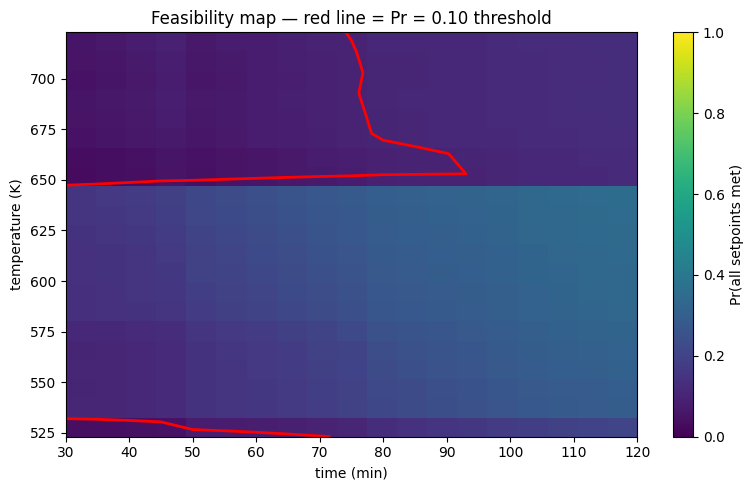

In [40]:
pivot = df_prob.pivot(index="temperature", columns="time",
                      values="pr_success_all")
plt.figure(figsize=(8, 5))
plt.imshow(pivot.values, aspect="auto", origin="lower",
           extent=[pivot.columns.min(), pivot.columns.max(),
                   pivot.index.min(), pivot.index.max()],
           cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Pr(all setpoints met)")
plt.contour(pivot.columns, pivot.index, pivot.values,
            levels=[1 - DELTA], colors="red", linewidths=2)
plt.xlabel("time (min)"); plt.ylabel("temperature (K)")
plt.title(f"Feasibility map — red line = Pr = {1-DELTA:.2f} threshold")
plt.tight_layout(); plt.show()

# 7. Cost functions + risk-aware value

Operational cost (lower T, lower t = cheaper) and a physics budget proxy (T*t),
both normalised. Plus one-sided 95% bounds so that, among equally-cheap cells, the
controller can prefer the one whose guarantee is robust: an **LCB** (`mu - kappa*sigma`)
for the floors — worst credible IACS / tensile strength — and a **UCB**
(`mu + kappa*sigma`) for the ceilings, i.e. the closest elongation credibly gets to
its maximum.

In [41]:
df_cost = pev.add_cost_function(
    pev.add_cost_function_physics(df_feasible),
    operational_limits=OPERATIONAL_LIMITS,
)

# One call covers both directions: {t}_lcb for every floor (MIN_SETPOINTS),
# {t}_ucb for every ceiling (MAX_SETPOINTS).
df_cost = pev.add_risk_adjusted_values(
    df_cost, MIN_SETPOINTS, MAX_SETPOINTS, kappa=KAPPA,
)

cost_cols = ["temperature", "time", "cost", "cost_phys"]
for t in MIN_SETPOINTS:
    cost_cols += [f"{t}_mu", f"{t}_lcb"]
for t in MAX_SETPOINTS:
    cost_cols += [f"{t}_mu", f"{t}_ucb"]
cost_cols += ["pr_success_all"]
df_cost[cost_cols].sort_values("cost").head()

,temperature,time,cost,cost_phys,iacs_mu,iacs_lcb,tensile_strength_mu,tensile_strength_lcb,elongation_mu,elongation_ucb,pr_success_all
19,533,30,0.050000,0.000000,98.345209,95.888478,294.880873,288.005751,19.405942,25.342068,0.107124
38,543,30,0.100000,0.004239,98.374569,95.978859,294.880873,288.006170,19.405942,25.336730,0.105024
20,533,35,0.105556,0.037657,98.392021,95.973753,294.878138,288.006061,19.405942,25.338734,0.109372
57,553,30,0.150000,0.008478,98.432335,96.107746,294.804768,287.930574,19.335341,25.160891,0.105486
39,543,35,0.155556,0.042603,98.421723,96.058445,294.878138,288.006416,19.405942,25.333473,0.107893


# 8. Select operating points

In [42]:
# Labels + columns generated from the SAME validated short names.
SELECTION_SPEC_HIGH = pev.build_probability_selection_spec(targets)

selected_low = pev.select_lowest_by_features(df_cost, SELECTION_SPEC_LOW)
selected_high = pev.select_highest_by_features(df_cost, SELECTION_SPEC_HIGH)

# Most engineering margin, per constraint direction:
#   floors   -> highest {t}_lcb (furthest above the minimum)
#   ceilings -> lowest  {t}_ucb (furthest below the maximum)
selected_high.update(
    pev.select_highest_by_features(df_cost, pev.build_lcb_selection_spec(MIN_SETPOINTS))
)
selected_low.update(
    pev.select_lowest_by_features(df_cost, pev.build_margin_selection_spec(MAX_SETPOINTS))
)

selected = {**selected_low, **selected_high}

for label, sub in selected.items():
    if len(sub):
        r = sub.iloc[0]
        print(f"{label:24s} -> T={r['temperature']:.0f}K t={r['time']:.0f}min "
              f"| iacs_mu={r['iacs_mu']:.2f} (+/-{r['iacs_sigma']:.2f}) "
              f"| elong_mu={r['elongation_mu']:.2f} (max {MAX_SETPOINTS['elongation']:.0f}) "
              f"| Pr_all={r['pr_success_all']:.3f}")

lowest_time              -> T=533K t=30min | iacs_mu=98.35 (+/-1.49) | elong_mu=19.41 (max 50) | Pr_all=0.107
lowest_temperature       -> T=523K t=75min | iacs_mu=98.64 (+/-1.25) | elong_mu=21.00 (max 50) | Pr_all=0.106
lowest_cost              -> T=533K t=30min | iacs_mu=98.35 (+/-1.49) | elong_mu=19.41 (max 50) | Pr_all=0.107
lowest_cost_phys         -> T=533K t=30min | iacs_mu=98.35 (+/-1.49) | elong_mu=19.41 (max 50) | Pr_all=0.107
most_margin_elongation   -> T=593K t=45min | iacs_mu=98.61 (+/-1.57) | elong_mu=19.34 (max 50) | Pr_all=0.156
safest_iacs              -> T=723K t=120min | iacs_mu=100.02 (+/-1.24) | elong_mu=52.00 (max 50) | Pr_all=0.132
safest_tensile_strength  -> T=523K t=75min | iacs_mu=98.64 (+/-1.25) | elong_mu=21.00 (max 50) | Pr_all=0.106
safest_elongation        -> T=533K t=30min | iacs_mu=98.35 (+/-1.49) | elong_mu=19.41 (max 50) | Pr_all=0.107
safest_combined          -> T=643K t=120min | iacs_mu=99.35 (+/-2.33) | elong_mu=19.03 (max 50) | Pr_all=0.353
most_ma

In [43]:
# The "best for production" pick: cheapest cell that is also safe.
# (df_cost already passed the delta gate, so any of these is feasible.)
selected["lowest_cost"]

,purity,material_reference,initial_diameter,iacs,tensile_strength,elongation,temperature,time,IRI,GBEI,...,pr_success_elongation,pr_success_all,iacs_margin_min,tensile_strength_margin_min,elongation_margin_max,cost_phys,cost,iacs_lcb,tensile_strength_lcb,elongation_ucb
0,99.6985,SN027,1.0,94.4,250.0,6.39,533,30,0.542737,0.268018,...,1.0,0.107124,-1.854791,84.880873,30.594058,0.0,0.05,95.888478,288.005751,25.342068


# 9. Inspect specific (T, t) pairs

Same targeted inspection the deterministic notebook offered, now with full
distribution + probability columns.

In [44]:
df_pairs = pev.filter_by_temperature_time_pairs(
    df_prob, temperatures=[573, 623, 673], times=[30, 60, 90],
)
df_pairs["temperature_C"] = df_pairs["temperature"] - 273

pair_cols = ["temperature_C", "time"]
for t in targets:
    pair_cols += [f"{t}_mu", f"{t}_sigma", f"pr_success_{t}"]
    # margin column: floors get _margin_min, ceilings _margin_max
    pair_cols += [c for c in (f"{t}_margin_min", f"{t}_margin_max")
                  if c in df_pairs.columns]
pair_cols += ["pr_success_all"]
df_pairs[pair_cols]

,temperature_C,time,iacs_mu,iacs_sigma,pr_success_iacs,iacs_margin_min,tensile_strength_mu,tensile_strength_sigma,pr_success_tensile_strength,tensile_strength_margin_min,elongation_mu,elongation_sigma,pr_success_elongation,elongation_margin_max,pr_success_all
95,300,30,98.505458,1.382460,0.110146,-1.694542,294.804768,4.178384,1.000000,84.804768,19.335341,3.537759,1.000000,30.664659,0.110146
101,300,60,98.891808,1.413003,0.177262,-1.308192,289.854803,4.182881,1.000000,79.854803,21.013793,4.622903,1.000000,28.986207,0.177262
107,300,90,99.181890,1.649829,0.268430,-1.018110,289.877075,4.171446,1.000000,79.877075,20.913312,4.902627,1.000000,29.086688,0.268430
190,350,30,98.563315,1.562323,0.147396,-1.636685,289.348888,4.516278,1.000000,79.348888,16.981767,8.762347,0.999918,33.018233,0.147384
196,350,60,98.927870,1.736520,0.231728,-1.272130,284.464827,4.356472,1.000000,74.464827,18.648999,5.433940,1.000000,31.351001,0.231728
202,350,90,99.181279,1.996874,0.303728,-1.018721,284.486694,4.319612,1.000000,74.486694,18.567080,5.339082,1.000000,31.432920,0.303728
285,400,30,99.322032,0.694749,0.103165,-0.877968,245.176890,5.399750,1.000000,35.176890,50.390548,6.244728,0.475066,-0.390548,0.049010
291,400,60,99.655193,0.842122,0.258834,-0.544807,240.572439,6.756473,0.999997,30.572439,52.209816,3.986483,0.289677,-2.209816,0.074978
297,400,90,99.861569,1.073121,0.376240,-0.338431,240.588483,7.025843,0.999993,30.588483,52.349258,4.266311,0.290936,-2.349258,0.109461


# 10. Export selections

In [45]:
IDENTIFIER = "uncertainty_aware_pilot"
output_dir = Path(varv.PATHS.data_enriched) / "mbc_annealing_uncertainty"

# Shared export (same method script_mbc_annealing_uncertainty.py calls):
# lean stakeholder layout, explicit column order from the validated targets,
# saved to <output_dir>/<IDENTIFIER>/mbc_ann_unc.csv. Fix the method in
# ProbabilisticEvaluation once -> notebook AND script are fixed.
out_path = pev.export_selections(
    selected, output_dir, IDENTIFIER, targets=targets,
)
print(f"Exported to: {out_path}")


2026-09-04 19:56:40,442 | INFO | src.metrics.ProbabilisticEvaluation | Exported 11 selections to ..\..\data\enriched\mbc_annealing_uncertainty\uncertainty_aware_pilot\mbc_ann_unc.csv


Exported to: ..\..\data\enriched\mbc_annealing_uncertainty\uncertainty_aware_pilot\mbc_ann_unc.csv
